### Download data through API from Kaggle

In [152]:
from matplotlib.pylab import f
import requests
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

with open(r"C:\Users\User\Desktop\Kaggle\kaggle.json") as file:
    creds = json.load(file)
    
username = creds["username"]
key = creds["key"]

dataset = "rohitgrewal/airlines-flights-data"
filename = "airlines-flights-data.zip"

url = f"https://www.kaggle.com/api/v1/datasets/download/{dataset}"

response = requests.get(url, auth=(username, key))

if response.status_code == 200:
    # Save file locally
    Path(filename).write_bytes(response.content)
    print(f"{filename} downloaded successfully.")
else:
    print(f"Failed to download {filename}. Status code: {response.status_code}")

airlines-flights-data.zip downloaded successfully.


### Extracting Zip file


In [153]:
import zipfile

from sqlalchemy import exists

file_path = Path(r"C:\Users\User\Desktop\Data Analyst\End To End Project\airline\airlines-flights-data.zip")
extract_path = Path(r"C:\Users\User\Desktop\Data Analyst\End To End Project\airline")

#extract_path.mkdir(extract_path, exists_ok=True)

# Extract
with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    


### Initial Inspection

- Quick checks: row/column counts, datatypes, null counts, unique keys, date ranges, obvious anomalies.
- Tools: pandas df.info()/describe(), SQL queries, DataProfiler.
- Deliverable: short EDA report with key stats and issues.

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\User\Desktop\Data Analyst\End To End Project\airline\airlines_flights_data.csv", index_col=False)
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [156]:
# drop index columns
df.drop(columns = ['index'], inplace=True)
print(df.head())

    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  


In [157]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [158]:
df[df.duplicated()]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


In [159]:
df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

### EDA

##### Total Flights per Airline

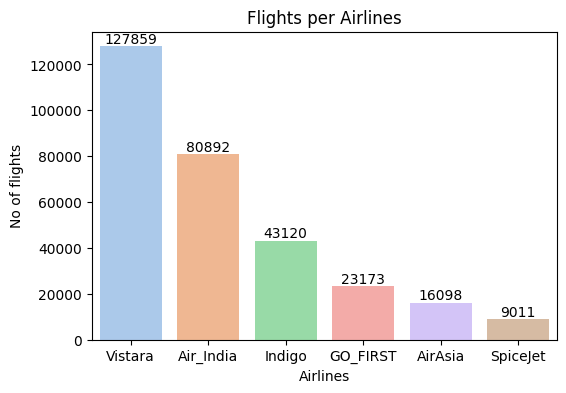

In [160]:
plt.figure(figsize= (6,4))
color = sns.color_palette("pastel")
ax = sns.barplot(x=df['airline'].value_counts().index, y=df['airline'].value_counts().values, palette=color)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Airlines')
plt.ylabel('No of flights')
plt.title('Flights per Airlines')
plt.show()

##### Price Distributions of Flights

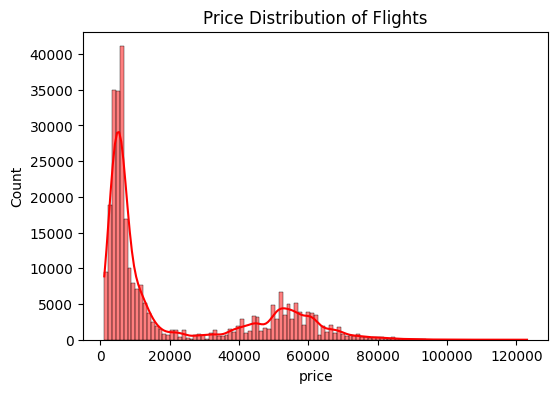

In [161]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], kde=True, color='r')
plt.title('Price Distribution of Flights')
plt.show()


##### Distribution of Flights per Departure/Arrival Destination

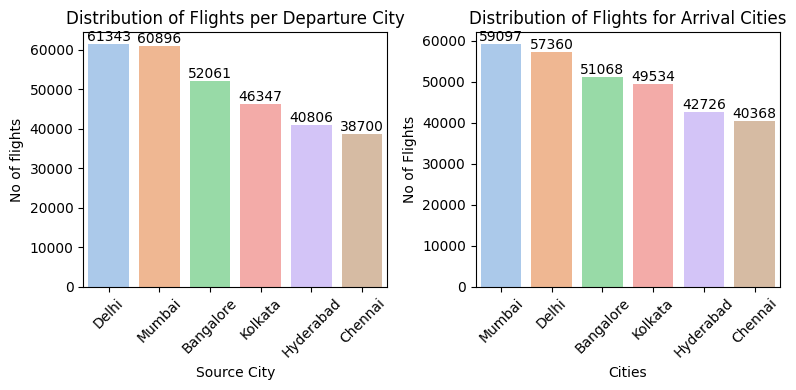

In [162]:
plt.figure(figsize=(8, 4))

plt.subplot(1,2,1)
ax = sns.barplot(x=df['source_city'].value_counts().index, y = df['source_city'].value_counts().values, palette=color)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Source City')
plt.ylabel('No of flights')
plt.title('Distribution of Flights per Departure City')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(1,2,2)
ax =sns.barplot(x=df['destination_city'].value_counts().index, y=df['destination_city'].value_counts().values, palette=color)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Cities")
plt.ylabel("No of Flights")
plt.title("Distribution of Flights for Arrival Cities")
plt.xticks(rotation=45)
plt.tight_layout()


##### Distributions Flights Time Variable

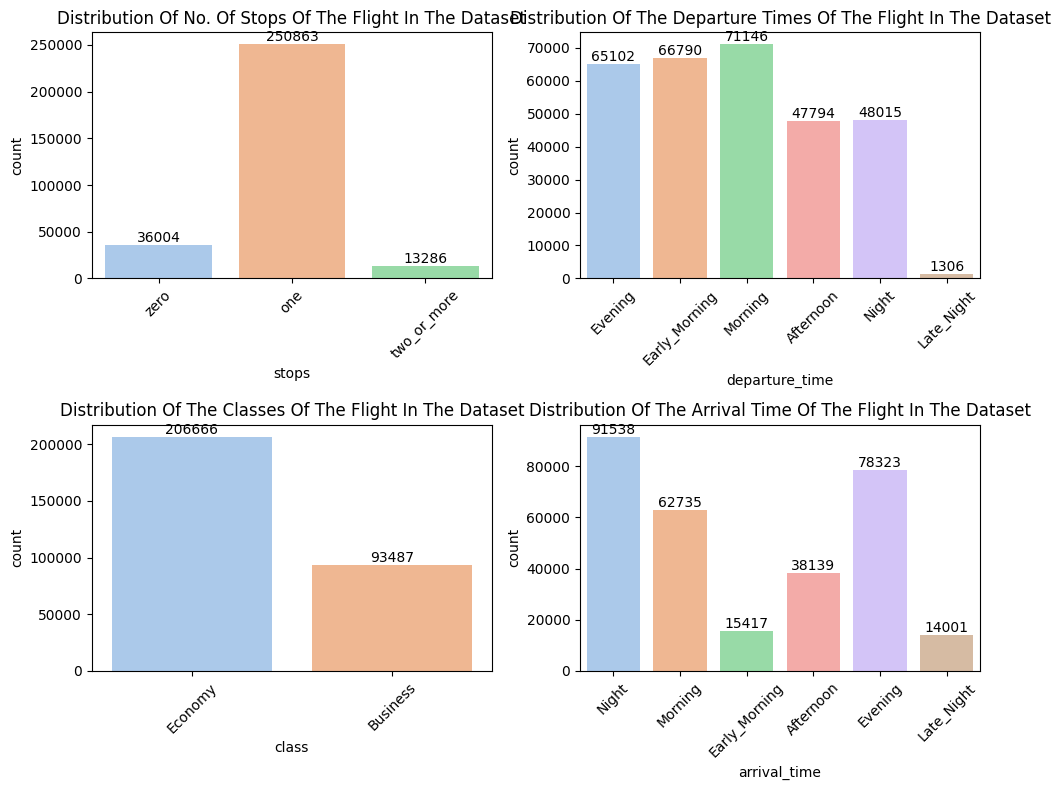

In [163]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
ax=sns.countplot(x=df['stops'], palette='pastel')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Distribution Of No. Of Stops Of The Flight In The Dataset')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(2,2,2)
ax=sns.countplot(x=df['departure_time'], palette='pastel')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Distribution Of The Departure Times Of The Flight In The Dataset')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(2,2,3)
ax=sns.countplot(x=df['class'], palette='pastel')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Distribution Of The Classes Of The Flight In The Dataset')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(2,2,4)
ax=sns.countplot(x=df['arrival_time'], palette='pastel')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Distribution Of The Arrival Time Of The Flight In The Dataset')
plt.xticks(rotation=45)
plt.tight_layout()


##### Top 5 Most Popular Routes

<Figure size 600x400 with 0 Axes>

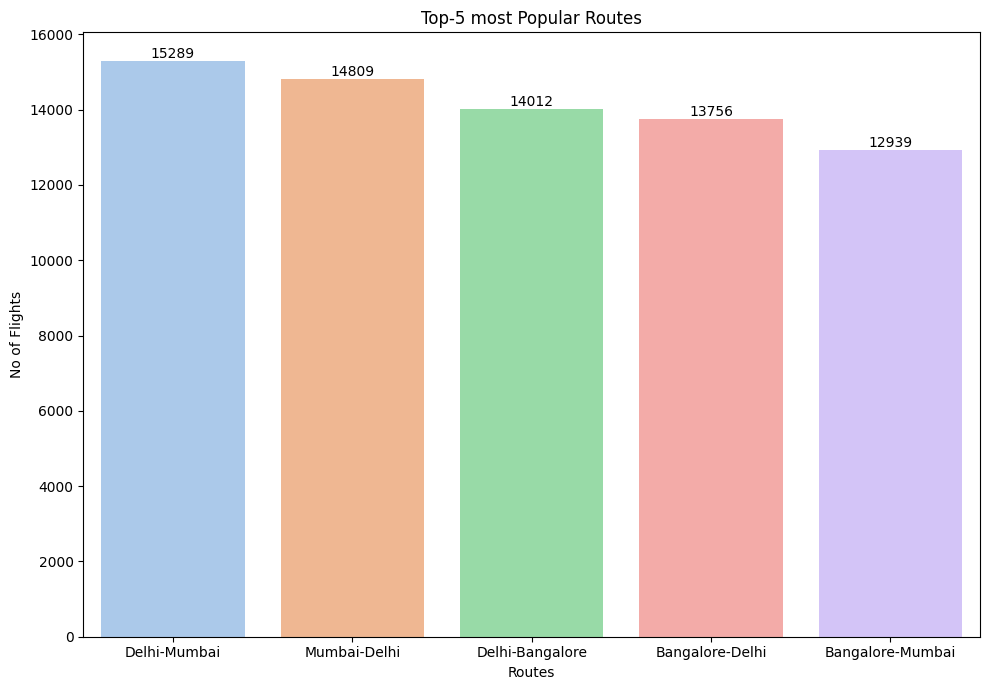

In [164]:

plt.figure(figsize=(6,4))
df['route']=df['source_city'] + "-" + df['destination_city']
plt.figure(figsize=(10,7))
ax =sns.barplot(x=df['route'].value_counts().sort_values(ascending=False)[:5].index, y=df['route'].value_counts().sort_values(ascending=False)[:5].values, palette=color)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Routes")
plt.ylabel("No of Flights")
plt.title("Top-5 most Popular Routes")
plt.tight_layout()

##### Top 5 Least Popular Routes

Text(0.5, 1.0, 'Top-5 Least Popular Routes')

<Figure size 600x400 with 0 Axes>

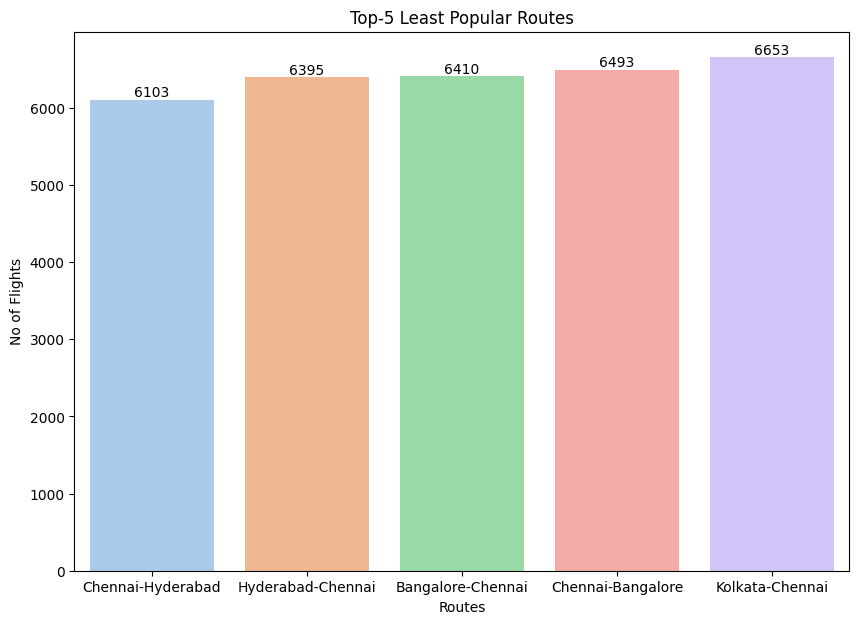

In [165]:
plt.figure(figsize=(6,4))
df['route']=df['source_city']+ "-"+ df['destination_city']
plt.figure(figsize=(10,7))
ax =sns.barplot(x=df['route'].value_counts().sort_values()[:5].index, y=df['route'].value_counts().sort_values()[:5].values, palette=color)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Routes")
plt.ylabel("No of Flights")
plt.title("Top-5 Least Popular Routes")

##### Average Price based on flight days left

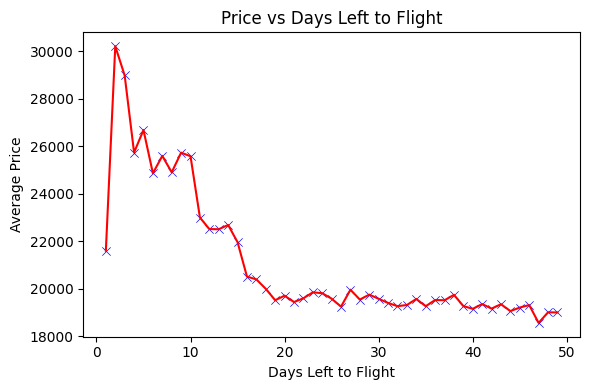

In [166]:
price_by_days_left = df.groupby('days_left')['price'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.scatterplot(x='days_left', y='price', data=price_by_days_left, marker = 'x', color='b')
sns.lineplot(x='days_left', y='price', data=price_by_days_left, color='r')
plt.title('Price vs Days Left to Flight')
plt.xlabel('Days Left to Flight')
plt.ylabel('Average Price')
plt.tight_layout()



##### Changes in Price by Days Left (by Airline)

<Figure size 1800x1000 with 0 Axes>

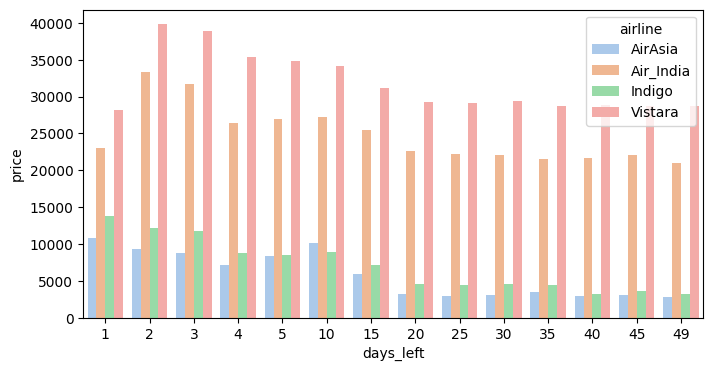

In [167]:
price_by_days_left_airline = df.groupby(['days_left', 'airline'])['price'].mean().reset_index()

#filter by airlines & days left
price_by_daysleft_and_airline_filtered=price_by_days_left_airline[(price_by_days_left_airline['days_left'].isin([1,2,3,4,5,10,15,20,25,30,35,40,45,49])
                                                                                                                     & (price_by_days_left_airline['airline'].isin(['AirAsia','Air_India','Indigo','Vistara'])))]
plt.figure(figsize=(18,10))

plt.figure(figsize=(8,4))
ax = sns.barplot(data=price_by_daysleft_and_airline_filtered, x='days_left', y='price', hue='airline', palette='pastel')

##### Average price based on destination route


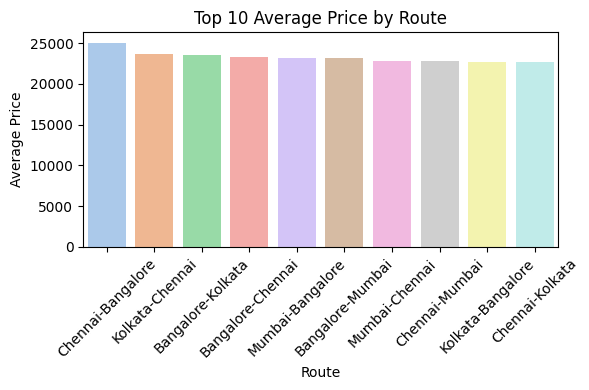

In [168]:
df.head()
top10_avg_route_price = df.groupby('route')['price'].mean().sort_values(ascending=False)[:10]
top10_avg_route_price

plt.figure(figsize=(6,4))
sns.barplot(x = top10_avg_route_price.index, y = top10_avg_route_price.values, palette='pastel')
plt.xticks(rotation=45)
plt.xlabel('Route')
plt.ylabel('Average Price')
plt.title('Top 10 Average Price by Route')
plt.tight_layout()
plt.show()

#### Saving Data to Database



In [180]:
from sqlalchemy import create_engine
import pyodbc

#print(pyodbc.drivers())

server = r"NASRULKHAIR\SQLEXPRESS"
database = "Data Warehouse"
driver = "ODBC+Driver+17+for+SQL+Server"
conn_str = f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"

try:
    engine = create_engine(conn_str)
    df.to_sql('airline_flights_data', con=engine, if_exists='replace', index=False)
    print("Data saved to database successfully.")
except Exception as e:
    print(f"An error occurred: {e}")


Data saved to database successfully.
